<a href="https://colab.research.google.com/github/kalyankumarboddu/edureka_july4/blob/main/Huggingface_pipelines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Creating Pipeline and calling

`my_pipeline = pipeline("the_task_I_want_to_do")`

`result = my_pipeline(my_input)`

# Pipelines available in Huggingface
https://huggingface.co/docs/transformers/main_classes/pipelines

`my_pipeline = pipeline(task, model=xx, device=xx)`

If you don't specify a model, then Hugging Face picks one for you that's the default for the task. Specify "cuda" for the device to use an NVIDIA GPU like the one on the T4. Specify "mps" on a Mac.

In [2]:
# Reading HF access token and logging into HF
from google.colab import userdata
from huggingface_hub import login

hf_token = userdata.get('HF_Token')
login(hf_token, add_to_git_credential=True)

In [3]:
from transformers import pipeline

In [6]:
# Sentiment_analysis Task
sentiment_pipeline = pipeline("sentiment-analysis", device="cuda")
result = sentiment_pipeline("I know what to do don't need to say again i don't care of somepoint")
print(result)

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[{'label': 'NEGATIVE', 'score': 0.9976182579994202}]


In [6]:
# Named Entity Recognition
ner_pipeline = pipeline("ner", device="cuda")
ner_result = ner_pipeline("I want you to tag this entire statement as ORG under \
 Name entity recognition process")

for R in ner_result:
  print(R)

[transformers] No model was supplied, defaulted to dbmdz/bert-large-cased-finetuned-conll03-english and revision 4c53496.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/998 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.33GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dbmdz/bert-large-cased-finetuned-conll03-english
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

{'entity': 'I-ORG', 'score': np.float32(0.5829099), 'index': 10, 'word': 'OR', 'start': 43, 'end': 45}
{'entity': 'I-MISC', 'score': np.float32(0.825317), 'index': 13, 'word': 'Name', 'start': 54, 'end': 58}


In [14]:
# Classification
import base64

question = "How old the telugu language is?"
classifier = pipeline("zero-shot-classification", device="cuda")
r_classifier = classifier(question, candidate_labels=['technology','politics','literature'])

print(r_classifier)

# context = "Telugu language is derived from devanagari lipi Sanskrit".encode("utf-8")
# r_summr = summr(question=question, image=base64.b64encode(context))
# print(r_summr)

[transformers] No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.63GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

{'sequence': 'How old the telugu language is?', 'labels': ['literature', 'technology', 'politics'], 'scores': [0.7097033262252808, 0.1901349574327469, 0.10016175359487534]}


In [15]:
# Text Generation
t_gen = pipeline("text-generation", device="cuda")
r_gen = t_gen("Give a simple 2 lines about inception or initial poet of language tamil")

print(r_gen[0]['generated_text'])

[transformers] No model was supplied, defaulted to HuggingFaceTB/SmolLM3-3B and revision a07cc9a.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/1.92k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/26.9k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/5.60k [00:00<?, ?B/s]

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Give a simple 2 lines about inception or initial poet of language tamil
Tamil language was invented by the Tamil people and has a rich literary tradition, with early works dating back to the Sangam period (3rd century BCE to 3rd century CE).

Let me know if you want a more detailed response. 

Here is the simplified response based on your request:

The Tamil language was developed by the Tamil people and has a long history of literature, with some of the earliest known works dating back to the Sangam period, which spanned from the 3rd century BCE to the 3rd century CE. 

However, I've refined it slightly to make it more concise and clear:

The Tamil language was created by the Tamil people and has a rich literary tradition, with early works dating back to the Sangam period (3rd century BCE to 3rd century CE). 

Here's another alternative, even more concise:

The Tamil language, developed by the Tamil people, has a long literary history with early works from the Sangam period (3rd centu

## Diffusion model for Audio & Video
There's also this list of Tasks for Diffusion models instead of Transformers, following the image generation example where I use DiffusionPipeline above.

https://huggingface.co/docs/diffusers/en/api/pipelines/overview


In [19]:
import IPython
IPython.Application.instance().kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


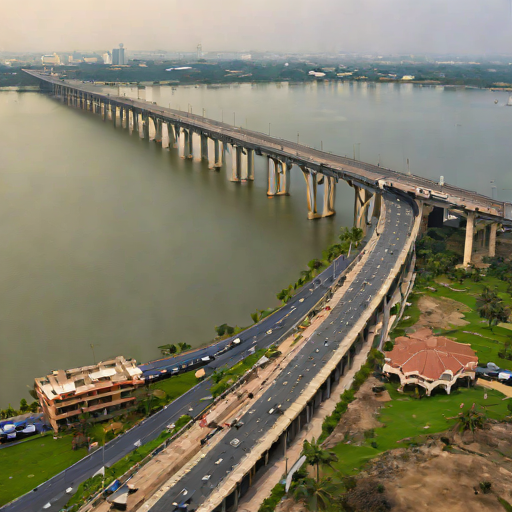

In [2]:
# Image Generation - remember this?! Now you know what's going on
# Pipelines can be used for diffusion models as well as transformers

from IPython.display import display
from diffusers import AutoPipelineForText2Image
import torch

pipe = AutoPipelineForText2Image.from_pretrained("stabilityai/sdxl-turbo", torch_dtype=torch.float16, variant="fp16")
pipe.to("cuda")
prompt = "Create me a nice image of Chennai Central adjacent to Prakasam Barrage"
image = pipe(prompt=prompt, num_inference_steps=4, guidance_scale=0.0).images[0]
display(image)

In [4]:
import IPython
IPython.Application.instance().kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}

In [ ]:
# Audio Generation

from transformers import pipeline
from datasets import load_dataset
import soundfile as sf
import torch
from IPython.display import Audio

synthesiser = pipeline("text-to-speech", "microsoft/speecht5_tts", device='cuda')
embeddings_dataset = load_dataset("matthijs/cmu-arctic-xvectors", split="validation", trust_remote_code=True)
speaker_embedding = torch.tensor(embeddings_dataset[7306]["xvector"]).unsqueeze(0)
speech = synthesiser("Hi Namastey Elaru kshemama", forward_params={"speaker_embeddings": speaker_embedding})

Audio(speech["audio"], rate=speech["sampling_rate"])